# Task 4 #

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from pathlib import Path
from chronos import ChronosBoltPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.utils.data import TensorDataset, DataLoader

from utilities.Task2_3a import load_and_preprocess_dataset, create_dataloader
from utilities.Task1 import STATIC_VARS
from utilities.training_functions import set_seed, run_training_pipeline, run_final_test
from utilities.plotting import plot_training_results, report_test_results
from utilities.dir_manager import clean_checkpoint_dir

from utilities.Task4_3 import (
    MLPAggregator, 
    extract_chronos_embeddings, 
    mean_aggregator, 
    identity_aggregator
)


/Users/lorenzofrigoli/Documents/UZH/MSc/ML_for_HC/ML4HC_Project1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 4.3 ##

In [3]:
PREPROCESSED_DIR = "output/preprocessed_imputed_datasets"
CLIP = 5.0
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
rnd_generator = torch.Generator()
set_seed(SEED)
SAVE_DIR = "model_checkpoints/task_4_3"

In [4]:
# Load the Chronos Bolt Small model
print(f"Loading Chronos model on {DEVICE}...")
chronos_model = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map=DEVICE,
    torch_dtype=torch.float32,
)

Loading Chronos model on cpu...


`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
# Identify dynamic variables by removing STATIC_VARS
df_a, ALL_COLS = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_a.parquet", "Set A", CLIP)
df_b, _ = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_b.parquet", "Set B", CLIP)
df_c, _ = load_and_preprocess_dataset(f"{PREPROCESSED_DIR}/preprocessed_set_c.parquet", "Set C", CLIP)

DYNAMIC_FEATURES = [col for col in ALL_COLS if col not in STATIC_VARS]

# Create dataloaders using only dynamic features for Chronos 
train_loader = create_dataloader(df_a, DYNAMIC_FEATURES, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = create_dataloader(df_b, DYNAMIC_FEATURES, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = create_dataloader(df_c, DYNAMIC_FEATURES, batch_size=BATCH_SIZE, shuffle=False)

Data clipped... for 52 features.
[Set A] No missing values found. (196000 rows)
[Set A] ✓ All 4000 patients have exactly 49 rows.
Data clipped... for 52 features.
[Set B] No missing values found. (196000 rows)
[Set B] ✓ All 4000 patients have exactly 49 rows.
Data clipped... for 52 features.
[Set C] No missing values found. (196000 rows)
[Set C] ✓ All 4000 patients have exactly 49 rows.


In [6]:
# Extract embeddings and aggregate with mean
print("Extracting training embeddings and aggregating with mean...")
X_train_emb, y_train = extract_chronos_embeddings(train_loader, chronos_model, identity_aggregator)
X_train_mean_emb = mean_aggregator(X_train_emb)

print("Extracting test embeddings and aggregating with mean...")
X_test_emb, y_test = extract_chronos_embeddings(test_loader, chronos_model, identity_aggregator)
X_test_mean_emb = mean_aggregator(X_test_emb)

print("\nExtracting Validation Embeddings for MLP Aggregator/Identity...")
X_val_raw, y_val = extract_chronos_embeddings(valid_loader, chronos_model, identity_aggregator)

print(f"Extraction complete. Feature matrix size: {X_train_emb.shape}")

Extracting training embeddings and aggregating with mean...
Extracting test embeddings and aggregating with mean...

Extracting Validation Embeddings for MLP Aggregator/Identity...
Extraction complete. Feature matrix size: torch.Size([4000, 48, 256])


In [7]:
# Convert torch tensors to numpy arrays for Scikit-Learn
X_train = X_train_mean_emb.numpy()
y_train_np = y_train.numpy()
X_test = X_test_mean_emb.numpy()
y_test_np = y_test.numpy()

# Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Train on the Chronos embeddings
print("Training Linear Probe on Chronos embeddings...")
logreg.fit(X_train, y_train_np)

# Evaluate on Test Set C
y_probs = logreg.predict_proba(X_test)[:, 1]

# Report metrics 
auroc = roc_auc_score(y_test_np, y_probs) 
auprc = average_precision_score(y_test_np, y_probs) 

print("-" * 35)
print(f"Chronos Linear Probe (Mean Aggregation):")
print(f"Test AuROC: {auroc:.4f}")
print(f"Test AuPRC: {auprc:.4f}")

Training Linear Probe on Chronos embeddings...
-----------------------------------
Chronos Linear Probe (Mean Aggregation):
Test AuROC: 0.6970
Test AuPRC: 0.2784


In [8]:
# get model embedding dimension
num_extracted_channels = X_train_emb.shape[1]
embed_dim = X_train_emb.shape[2]

# Smart Aggregator (MLP)
smart_aggregator = MLPAggregator(
    num_channels=num_extracted_channels, 
    embed_dim=embed_dim, 
    n_hidden=2, 
    hidden_dim=512
).to(DEVICE)

In [9]:
# Create DataLoaders for the extracted features with dummy masks for compatibility
# The training pipeline expects (data, mask, labels) during iteration.
train_masks = torch.ones(X_train_emb.shape[0], 1)
train_ds = TensorDataset(X_train_emb, train_masks, y_train.float())
fast_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=rnd_generator)

val_masks = torch.ones(X_val_raw.shape[0], 1)
eval_ds = TensorDataset(X_val_raw, val_masks, y_val.float())
fast_eval_loader = DataLoader(eval_ds, batch_size=64, shuffle=False, generator=rnd_generator)

test_masks = torch.ones(X_test_emb.shape[0], 1)
test_ds = TensorDataset(X_test_emb, test_masks, y_test.float())
fast_test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, generator=rnd_generator)

In [10]:
EPOCHS = 5 
optimizer = torch.optim.Adam(smart_aggregator.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=2
    )


Starting end-to-end training of MLP Aggregator head with ReduceLROnPlateau...
Epoch 01 | Train Loss: 0.4087 | Val Loss: 0.3385 | Val AuROC: 0.8126 | Val AuPRC: 0.4029
  >> Checkpoint synced to: model_checkpoints/task_4_3/run_20260331_152040
  * Best model updated (AuPRC: 0.4029)
Epoch 02 | Train Loss: 0.3210 | Val Loss: 0.3206 | Val AuROC: 0.8232 | Val AuPRC: 0.4581
  >> Checkpoint synced to: model_checkpoints/task_4_3/run_20260331_152040
  * Best model updated (AuPRC: 0.4581)
Epoch 03 | Train Loss: 0.3055 | Val Loss: 0.3111 | Val AuROC: 0.8314 | Val AuPRC: 0.4900
  >> Checkpoint synced to: model_checkpoints/task_4_3/run_20260331_152040
  * Best model updated (AuPRC: 0.4900)
Epoch 04 | Train Loss: 0.2800 | Val Loss: 0.3211 | Val AuROC: 0.8359 | Val AuPRC: 0.4989
  >> Checkpoint synced to: model_checkpoints/task_4_3/run_20260331_152040
  * Best model updated (AuPRC: 0.4989)
Epoch 05 | Train Loss: 0.2636 | Val Loss: 0.3201 | Val AuROC: 0.8318 | Val AuPRC: 0.4911
Cleaned plots saved to: 

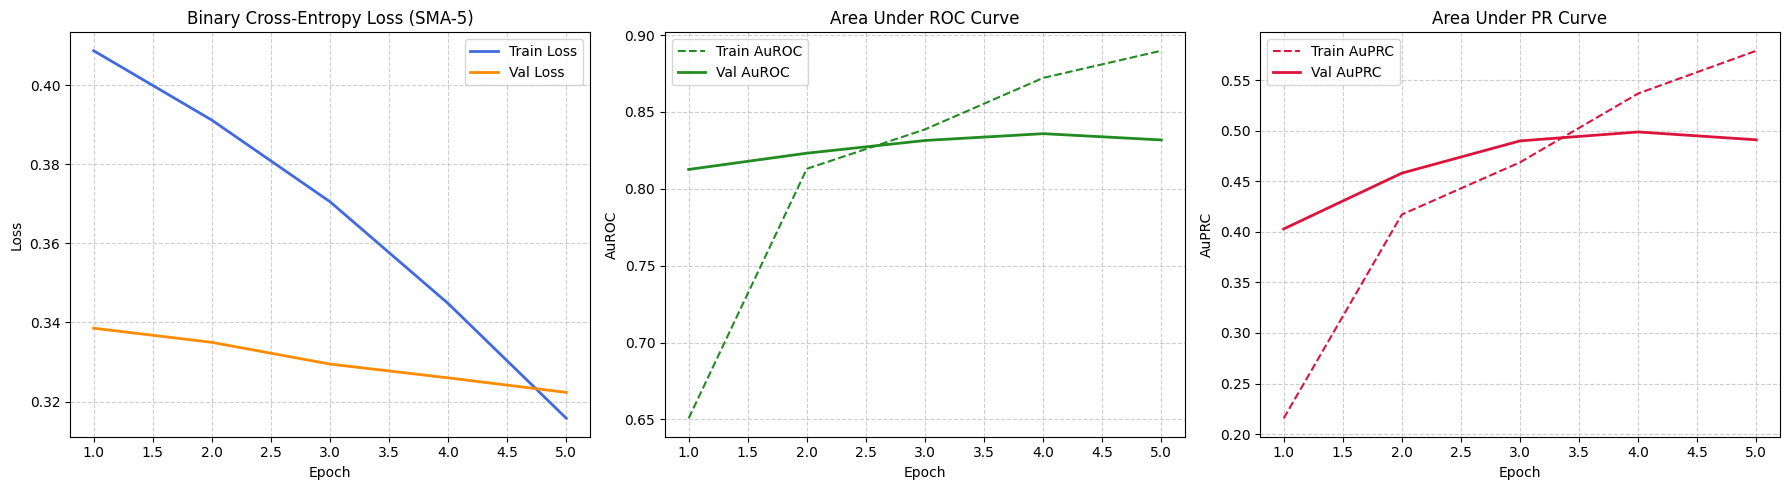

In [11]:
print("\nStarting end-to-end training of MLP Aggregator head with ReduceLROnPlateau...")
train_results = run_training_pipeline(
    model=smart_aggregator,
    optimizer=optimizer,
    train_loader=fast_train_loader,
    val_loader=fast_eval_loader,
    device=torch.device(DEVICE),
    scheduler=scheduler,  
    save_dir=SAVE_DIR,
    epochs=EPOCHS,
    data_format="dense"
)

# Plot results
plot_training_results(train_results["history"], save_path=Path(train_results["save_dir"]) / "training_curves.png")

In [12]:
# Final test evaluation
checkpoint_path = Path(train_results["save_dir"]) / "best_model.pt"
test_results = run_final_test(
    model=smart_aggregator,
    test_loader=fast_test_loader,
    checkpoint_path=str(checkpoint_path),
    device=torch.device(DEVICE),
    data_format="dense"
)

# Report results using formatted utility
report_test_results(test_results, model_name="Chronos-MLP-Aggregator")

# Cleanup directory preserving only the best run
clean_checkpoint_dir(SAVE_DIR, keep_run_name=train_results["run_name"])

Loading best model weights from: model_checkpoints/task_4_3/run_20260331_152040/best_model.pt
Starting final evaluation on Set C...

FINAL TEST RESULTS (SET C)
AuROC: 0.8353
AuPRC: 0.4731
Loss:  0.3346

 FINAL PERFORMANCE REPORT: Chronos-MLP-Aggregator
Metric          | Value     
----------------------------
AuROC           | 0.8353
AuPRC           | 0.4731
Test Loss       | 0.3346
---------------------------------------------
Chronos-MLP-Aggregator & 0.8353 & 0.4731 & 0.3346 \\

Cleaning directory: model_checkpoints/task_4_3
Keeping only: run_20260331_152040
  [Deleted] run_20260331_145717
  [Preserved] run_20260331_152040 (Best Model)

Cleanup complete. Removed 1 old run directories.
